## imports


In [1]:
print("Adaptation completed.")

Adaptation completed.


In [2]:
import os
import sys
import matplotlib.pyplot as plt
import torch

from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from mne_connectivity import spectral_connectivity_time

import warnings
warnings.filterwarnings("ignore", message="Using padding='same'", category=UserWarning)

In [3]:
dir_base = Path("../..")
print(os.path.abspath(dir_base))

c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg


In [4]:
sys.path.append(os.path.abspath(dir_base))

sys.path.append(
    os.path.abspath(os.path.join(dir_base, "backend", "experiments_xeegnet"))
)
sys.path.append(
    os.path.abspath(
        os.path.join(dir_base, "backend", "experiments_xeegnet", "shallownetXAI_main")
    )
)
sys.path.append(os.path.abspath(os.path.join(dir_base, "backend", "ml")))

sys.path.append("../")


In [5]:
%load_ext autoreload
%autoreload 2

from AllFnc.models import ShallowNet, ShallowNet2
from AllFnc.training import lossBinary, lossMulti, train_model, get_performances

from backend.ml.data_utils.load_data import *
from backend.ml.data_utils.prepare_data import *
from backend.experiments_xeegnet.xeegnet_with_conn import xEEGNetSCC


from backend.ml.model_vars import PRETRAINED_MODEL_DIR
from backend.ml.train import train_save_model, get_train_val_test_loader, PARAMETERS_DEFAULT, TRAINING_PARAMETERS_DEFAULT, save_model, load_model_weights
from main import load_participant_splits

from backend.ml.scc_cache import SCCStore, SCCParams, build_x_y_scc, CachedSCCDataset, SCCReducer, pairs_to_dense


import selfeeg

c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Read Data


#### function


In [6]:
def get_dataloaders_xysubjectids(
    dir_data: str, participant_ids_train: list[int], participant_ids_val: list[int], df_metadata: pd.DataFrame, parameters: dict, n_max: int = None):

    x_train, y_train, subject_ids_train = load_multiple_eeg_windows_inner(
        dir_data,
        participant_ids_train,
        df_metadata,
        sample_length=parameters["sample_length"],
        n_max=n_max,
    )
    x_val, y_val, subject_ids_val = load_multiple_eeg_windows_inner(
        dir_data,
        participant_ids_val,
        df_metadata,
        sample_length=parameters["sample_length"],
        n_max=n_max,
    )

    x_test, y_test, subject_ids_test = load_multiple_eeg_windows_inner(
        dir_data,
        df_metadata.loc[df_metadata["datasplit"] == "test", "participant_id_int"].tolist(),
        df_metadata,
        sample_length=parameters["sample_length"],
        n_max=n_max,
    )

    trainloader = get_window_data_loader(
        x_train,
        y_train,
        parameters["batchsize"],
        parameters["workers"],
    )
    valloader = get_window_data_loader(
        x_val,
        y_val,
        parameters["batchsize"],
        parameters["workers"],
        shuffle=False,
    )

    testloader = get_window_data_loader(
        x_test,
        y_test,
        parameters["batchsize"],
        parameters["workers"],
        shuffle=False,
    )

    return trainloader, valloader, testloader, (x_train, y_train, subject_ids_train, x_val, y_val, subject_ids_val, x_test, y_test, subject_ids_test)

#### paths


In [7]:
dir_data = os.path.join(dir_base, "data", "datasets", "ds004504")
dir_data_abs = os.path.abspath(dir_data)
data_path = os.path.join(dir_data, "sub-001", "eeg", "sub-001_task-eyesclosed_eeg.set")

dir_data_outer = os.path.join(dir_base, "data")

dir_shallownetXAI = os.path.join(
    dir_base, "backend", "experiments_xeegnet", "shallownetXAI_main"
)

# data_path = os.path.join(dir_data_abs, 'ds004504/sub-001/eeg/sub-001_task-eyesclosed_eeg.set')

## Settings


In [8]:
n_max = 1000
model_version = 200

### Metadata / y


In [9]:
df_metadata = load_metadata(dir_data=dir_data)
df_metadata.head()

,participant_id,Gender,Age,Group,MMSE,group_long,group_encoded,participant_id_int
0,sub-001,F,57,A,16,Alzheimer Disease Group,1,1
1,sub-002,F,78,A,22,Alzheimer Disease Group,1,2
2,sub-003,M,70,A,14,Alzheimer Disease Group,1,3
3,sub-004,F,67,A,20,Alzheimer Disease Group,1,4
4,sub-005,M,70,A,22,Alzheimer Disease Group,1,5


In [10]:
participant_ids = [1, 2, 3, 4, 5, 6, 40, 41, 42, 43, 44, 45, 80, 81, 82, 83, 84, 85]

df_eeg_small = load_multiple_eegfiles(
    dir_data=dir_data,
    participant_ids=participant_ids,  # , 43
    gen_path_func=gen_filename,
    df_metadata=df_metadata,
    n_max=150,
)

Total memory usage of combined df_eeg: 0.23 MB


In [11]:
print(df_eeg_small.shape)
df_eeg_small.head()

(2700, 22)


,time,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,...,F8,T3,T4,T5,T6,Fz,Cz,Pz,participant_id,diagnosis
0,0.000,-216.707306,-154.500626,-115.910667,18.374157,-119.257698,-46.773888,-83.129326,163.208298,149.883255,...,-126.152870,-70.800987,-22.987829,-77.447159,-142.291214,-113.576492,-28.376854,-136.401978,sub-001,1
1,0.008,-163.077789,-129.190735,-98.835381,38.559467,-97.636795,-26.175304,-64.038612,183.764389,149.042557,...,-98.163490,-47.460701,-1.328547,-79.095764,-120.501694,-92.966438,-8.048896,-117.015953,sub-001,1
2,0.016,-172.030151,-130.024796,-112.606117,41.594624,-101.570793,-23.207067,-66.826469,184.497833,149.262833,...,-101.406677,-52.894779,-4.642946,-81.475250,-121.560654,-93.725876,-7.764234,-115.192619,sub-001,1
3,0.024,-180.445724,-130.554886,-110.314621,38.854797,-102.682266,-25.941097,-68.745064,182.075104,152.322067,...,-98.266495,-51.201221,-5.227331,-77.432365,-124.645004,-95.773582,-8.484701,-119.355888,sub-001,1
4,0.032,-171.958725,-123.986397,-102.452408,47.651417,-96.679337,-18.863199,-62.647579,188.566895,151.180359,...,-92.241425,-50.356083,7.061250,-78.966293,-115.325089,-85.054092,-3.320512,-112.621025,sub-001,1


### Calculate spectral connectivity


In [12]:
from xeegnet_with_conn import BANDS

fmin = tuple(lo for lo, hi in BANDS.values())
fmax = tuple(hi for lo, hi in BANDS.values())

freqs = np.arange(1.0, 45.5, 1.0)  # 1..45 Hz in 1 Hz steps'
n_cycles = freqs / 2.0

In [13]:
subject = "sub-007"

data_path = os.path.join(
    dir_data, "derivatives", subject, "eeg", f"{subject}_task-eyesclosed_eeg.set"
)
eeg_data = load_preprocessed_raw_from_file(data_path)

In [14]:
sfreq = eeg_data.info["sfreq"]
window_sec = 4.0
epochs = mne.make_fixed_length_epochs(
    eeg_data, duration=window_sec, overlap=0.0, preload=True, verbose="ERROR"
)

window_index = 0
one_epoch = epochs[window_index]  # shape (1, n_channels, n_times)

In [15]:
con = spectral_connectivity_time(
    one_epoch,
    freqs=freqs,
    method="coh",
    mode="cwt_morlet",
    n_cycles=n_cycles,
    fmin=fmin,
    fmax=fmax,
    faverage=True,  # average within each band -> one value per band
    average=False,  # keep per-epoch (we only have 1 epoch anyway)
    sfreq=sfreq,
    verbose="ERROR",
)

In [16]:
# con.get_data() shape: (n_epochs, n_connections, n_bands)
# n_connections = n_channels**2 (flattened full matrix, most entries are the lower triangle)
data = con.get_data()  # (1, C*C, 5)
print(data.shape)

(1, 361, 7)


### visualize spectral connectivity


In [17]:
n_ch = len(one_epoch.ch_names)
# spectral_connectivity_time returns the full C*C flattened; reshape to (C, C, n_bands)
conn_matrix = data[0].reshape(n_ch, n_ch, len(BANDS))  # [X, Y, band]

# To reproduce DICE's SCC_x (eq. 4): average each channel's coherence with all others.
# DICE did: SCC_x = (1/C) * sum_y coherence(x,y)  -> collapses the Y axis -> one scalar per channel.
# Note: the connectivity matrix is lower-triangular (upper half is zeros); symmetrize first.
conn_sym = conn_matrix + np.transpose(conn_matrix, (1, 0, 2))  # mirror lower->upper
scc_per_channel = conn_sym.mean(axis=1)  # [C, band] -> DICE's per-channel SCC feature

print(f"shape of SCC per channel: {scc_per_channel.shape} (n_channels, n_bands)")

shape of SCC per channel: (19, 7) (n_channels, n_bands)


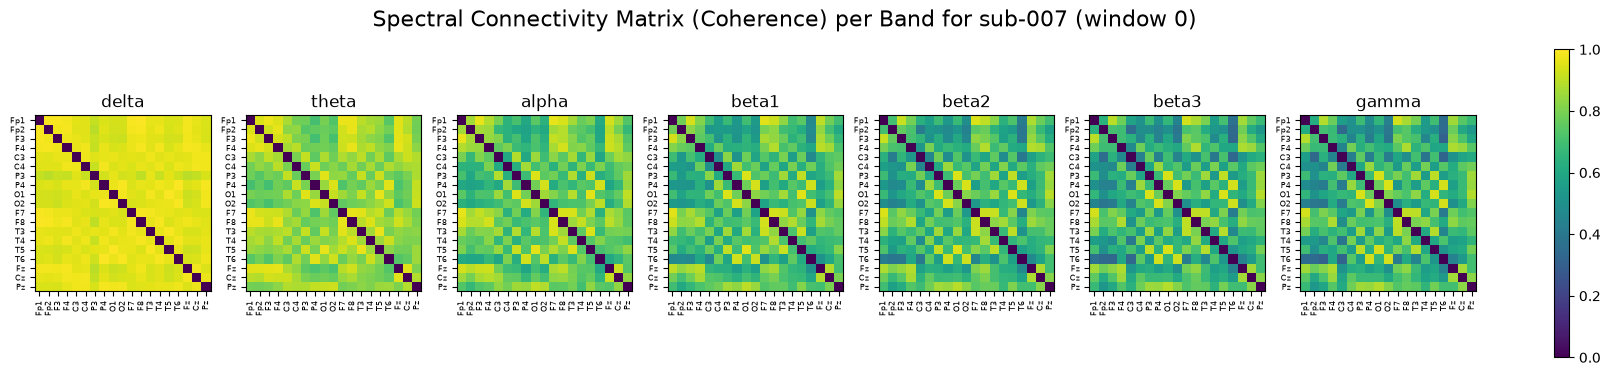

In [18]:
ch_names = one_epoch.ch_names
band_names = list(BANDS.keys())

fig, axes = plt.subplots(1, len(band_names), figsize=(20, 4))
for b, (ax, band) in enumerate(zip(axes, band_names)):
    im = ax.imshow(conn_sym[:, :, b], vmin=0, vmax=1, cmap="viridis")
    ax.set_title(band)
    ax.set_xticks(range(len(ch_names)))
    ax.set_yticks(range(len(ch_names)))
    ax.set_xticklabels(ch_names, rotation=90, fontsize=6)
    ax.set_yticklabels(ch_names, fontsize=6)
fig.colorbar(im, ax=axes, fraction=0.02)

plt.suptitle(f"Spectral Connectivity Matrix (Coherence) per Band for {subject} (window {window_index})", fontsize=16)

plt.show()

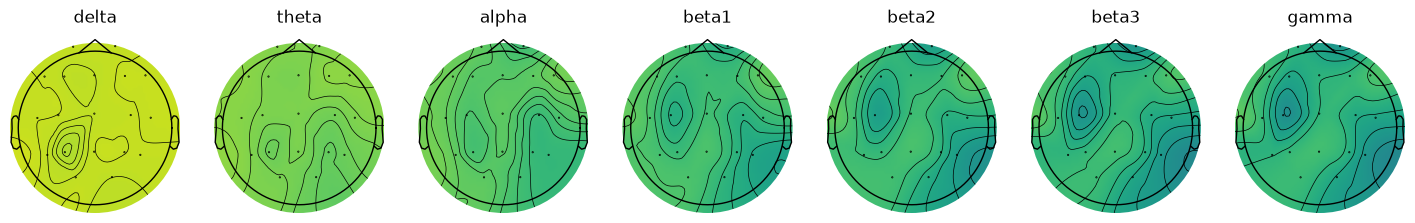

In [19]:
# needs a montage so MNE knows electrode positions
one_epoch.set_montage("standard_1020", on_missing="warn")

fig, axes = plt.subplots(1, len(band_names), figsize=(18, 4))
for b, (ax, band) in enumerate(zip(axes, band_names)):
    mne.viz.plot_topomap(
        scc_per_channel[:, b],
        one_epoch.info,
        axes=ax,
        show=False,
        vlim=(0, 1),
        cmap="viridis",
    )
    ax.set_title(band)
plt.show()

## self eeg with conn


In [20]:
def build_xeegnet_scc(nb_classes=3, Chans=19, Samples=125 * 4, Fs=125):
    return None
    base = selfeeg.models.xEEGNet(
        nb_classes=nb_classes,
        Chans=Chans,
        Samples=Samples,
        Fs=Fs,
        global_pooling=True,
    )
    xeegnet_scc = xEEGNetSCC(base_model=base, spec_kwargs={"Fs": Fs, "n_fft": 256})
    return xeegnet_scc

In [ ]:
# Base xEEGNet
base = selfeeg.models.xEEGNet(
    nb_classes=3,
    Chans=19,
    Samples=125 * 4,
    Fs=125,
    global_pooling=True,
 )
# Wrapper with cached spectral connectivity pairs
xeegnet_scc = xEEGNetSCC(base_model=base, reducer_mode="mean")

# # Smoke test input: (batch, channels, samples) plus cached SCC pairs
# torch.manual_seed(42)
# x = torch.randn(2, 19, 125 * 4)
# scc_pairs = torch.as_tensor(cached_scc[:2], dtype=torch.float32)
# out = xeegnet_scc([x, scc_pairs])

# print("input shape:", x.shape)
# print("scc shape:", scc_pairs.shape)
# print("output shape:", out.shape)
# print("contains NaN:", torch.isnan(out).any().item())
# out

xEEGNetSCC(
  (base): xEEGNet(
    (encoder): xEEGNetEncoder(
      (conv1): Conv2d(1, 7, kernel_size=(1, 125), stride=(1, 1), bias=False)
      (conv2): Conv2d(7, 7, kernel_size=(19, 1), stride=(1, 1), groups=7, bias=False)
      (batch1): BatchNorm2d(7, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (global_pooling): AdaptiveAvgPool2d(output_size=(1, 1))
      (drop1): Dropout(p=0.2, inplace=False)
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (Dense): Linear(in_features=7, out_features=3, bias=False)
  )
  (reducer): SCCReducer()
  (Dense): Linear(in_features=14, out_features=3, bias=False)
)

In [23]:
torch.manual_seed(42)
out = base(torch.randn(2, 19, 125 * 4))
out

tensor([[ 0.1325, -0.4139, -0.7727],
        [-0.0178,  0.2719,  0.5244]], grad_fn=<MmBackward0>)

# test models


#### settings


In [24]:
pipelineToEval = "filt"  #'icasr'
taskToEval = "alzheimer"
modelToEval = "shallownet_custom"  # shallownet, shallownet_custom
outFold = 1
inFold = 5
downsample = True
z_score = True
rem_interp = True
batchsize = 64
overlap = 0.0
workers = 0
window = 4
verbose = True
lr = 5 * 10 ** (-5)
epochs = 1000
lossVal = None
arch_acronym = "shn7db"
seed = 83136297

In [25]:
nb_classes = 3
Chans = 19
srate = 125 if downsample else 250

sample_length = 125 * 4  # srate * window

In [26]:
# Med-ShallowNet
shallownet_custom_dict = {
    "F1": 7,
    "K1": 125,
    "F2": 7,
    "Pool": 75,
    "p": 0.2,
    "log_activation_base": "dB",
    "norm_type": "batchnorm",
    "random_temporal_filter": False,
    "Fs": 125 if downsample else 250,
    "freeze_temporal": 999999999,
    "dense_hidden": None,
    "spatial_depthwise": True,
    "spatial_only_positive": False,
    "global_pooling": True,
    "bias": [False, False, False],
    "return_logits": True,
    "seed": seed,
}

In [28]:
# SET DEVICE: 0 = ZANOLA
if torch.cuda.is_available():
    device = torch.device(0)
else:
    device = torch.device("cpu")
print(device)

cpu


### Generate models


In [57]:
# For selfEEG's models instantiation
sample_length = int(srate * window)
shallow_net_2 = ShallowNet2(
    nb_classes=nb_classes, Chans=Chans, Samples=sample_length, seed=seed
)
shallow_net = ShallowNet(
    nb_classes=nb_classes, Chans=Chans, Samples=sample_length, seed=seed
)

xeegnet = selfeeg.models.xEEGNet(
    nb_classes=nb_classes,
    Chans=Chans,
    Samples=sample_length,
    Fs=125 if downsample else 250,
    global_pooling=True,
)

#### Test forward pass


In [58]:
n_batches = 10

x = torch.randn(n_batches, Chans, sample_length, dtype=torch.float32)
scc_pairs = torch.randn(n_batches, len(BANDS), Chans*(Chans-1)//2, dtype=torch.float32)

out = xeegnet_scc([x, scc_pairs])
print(out.shape)  # shoud return torch.Size([3, 3])
print(torch.isnan(out).sum())  # shoud return 0
out

torch.Size([10, 3])
tensor(0)


tensor([[-0.0998, -0.1832,  0.7709],
        [ 0.0247, -0.0916,  0.1518],
        [ 0.6598, -0.2750, -0.9013],
        [-0.2131,  0.0052,  0.1249],
        [-0.5405,  0.5245,  0.5389],
        [ 0.9982, -0.3144,  0.2780],
        [ 0.0345,  0.1921, -0.5895],
        [-0.3068, -0.0449,  0.9802],
        [-0.1296,  0.3080, -0.8865],
        [ 1.1677, -0.8381,  0.7078]], grad_fn=<MmBackward0>)

In [59]:
def inference(model, x: torch.Tensor | np.ndarray):
    model.eval()

    if isinstance(x, np.ndarray):
        x = torch.from_numpy(x).float()
    with torch.no_grad():
        out = model(x)
    return out

In [60]:
# out = inference(xeegnet, x_input)
# print(out.shape)
# out

## calculating spectral connectivity cache


In [40]:
participant_ids = [2,3]

# 4 - 88
participant_ids = np.arange(1, 89).tolist()
print(participant_ids)
# participant_ids

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88]


In [41]:
path=Path(dir_data_outer) / "scc_cache" / "ds004504" / "derivatives" 
path

store  = SCCStore(
    root=Path(dir_data_outer) / "scc_cache" 
)
params = SCCParams.default(sfreq=srate, sample_length=sample_length)

In [42]:
from backend.ml.scc_cache import SCCStore, SCCParams, precompute_dataset

# subjects = [
#     (f"sub-{pid:03d}", load_model_windows_for_participant(dir_data, pid, sample_length=sample_length)[0])
#     for pid in participant_ids
# ]  # [0] takes the windows out of (windowsy, sfreq, ranges)

# precompute_dataset(store, "ds004504", subjects, params, n_channels=Chans, n_jobs=-1, verbose=True, chunk_size=None, progress=None)

In [ ]:
# #  # from backend.data.load_data import load_model_windows_for_participant, load_metadata

df   = load_metadata(dir_data)
label_of = {f"sub-{int(r.participant_id.split('-')[1]):03d}": int(r.group_encoded)
            for r in df.itertuples()}

x, y, scc, sids = build_x_y_scc(
    dir_data, participant_ids, label_of, store, params,
    load_model_windows_for_participant,
    dataset_id="ds004504", n_channels=Chans, source="derivatives",  
    sample_length=sample_length,
)

print(x.shape)
print(y.shape)
print(scc.shape)
print(sids.shape)
print(x)
print(y)
print(scc)
print(sids)

train_ds = CachedSCCDataset(x, scc, y)  # yields ([x, scc], y)

  cache hit for sub-001 (derivatives) -> (149, 7, 171)
  cache hit for sub-002 (derivatives) -> (198, 7, 171)
  cache hit for sub-003 (derivatives) -> (76, 7, 171)
  cache hit for sub-004 (derivatives) -> (176, 7, 171)
  cache hit for sub-005 (derivatives) -> (201, 7, 171)
  cache hit for sub-006 (derivatives) -> (158, 7, 171)
  cache hit for sub-007 (derivatives) -> (191, 7, 171)
  cache hit for sub-008 (derivatives) -> (198, 7, 171)
  cache hit for sub-009 (derivatives) -> (153, 7, 171)
  cache hit for sub-010 (derivatives) -> (320, 7, 171)
  cache hit for sub-011 (derivatives) -> (192, 7, 171)
  cache hit for sub-012 (derivatives) -> (220, 7, 171)
  cache hit for sub-013 (derivatives) -> (209, 7, 171)
  cache hit for sub-014 (derivatives) -> (233, 7, 171)
  cache hit for sub-015 (derivatives) -> (225, 7, 171)
  cache hit for sub-016 (derivatives) -> (243, 7, 171)
  cache hit for sub-017 (derivatives) -> (210, 7, 171)
  cache hit for sub-018 (derivatives) -> (211, 7, 171)
  cache hit

## Load and visualize cached SCC

The cache stores raw pair vectors, not the full MNE connectivity object. Use `store.get(...)` to load a subject's cached array, then `pairs_to_dense(...)` to reconstruct a symmetric band-by-channel matrix for plotting.


In [43]:
import json

dataset_id = "ds004504"
# subject_id = "sub-001"
subject_id = "sub-007"
source = "derivatives"

cached_scc = store.get(dataset_id, subject_id, source, params)
if cached_scc is None:
    raise FileNotFoundError(
        f"No cached SCC found for {subject_id}. Precompute the cache first or check params.key()."
    )

cache_json_path = store._json_path(dataset_id, subject_id, source, params.key())
cache_npy_path = store._npy_path(dataset_id, subject_id, source, params.key())
cache_meta = json.loads(cache_json_path.read_text(encoding="utf-8"))

print("cached_scc type:", type(cached_scc))
print("cached_scc dtype / shape:", cached_scc.dtype, cached_scc.shape)
print("sidecar type:", type(cache_meta))
print("sidecar keys:", sorted(cache_meta.keys()))
print("npy path:", cache_npy_path)
print("json path:", cache_json_path)

# One cached window is a raw pair tensor: (n_bands, n_pairs)
window_idx = 0
cached_window = cached_scc[window_idx]
print("one window type / shape:", type(cached_window), cached_window.shape)

cached_scc type: <class 'numpy.ndarray'>
cached_scc dtype / shape: float32 (191, 7, 171)
sidecar type: <class 'dict'>
sidecar keys: ['band_edges', 'band_names', 'created_at', 'dataset_id', 'method', 'mode', 'n_bands', 'n_channels', 'n_pairs', 'n_windows', 'pair_convention', 'sample_length', 'scc_cache_version', 'scc_key', 'sfreq', 'source', 'subject_id']
npy path: ..\..\data\scc_cache\ds004504\scc-f1c09c5a2124ee89\subjects\sub-007.derivatives.scc.npy
json path: ..\..\data\scc_cache\ds004504\scc-f1c09c5a2124ee89\subjects\sub-007.derivatives.scc.json
one window type / shape: <class 'numpy.ndarray'> (7, 171)


conn_dense shape: (7, 19, 19)


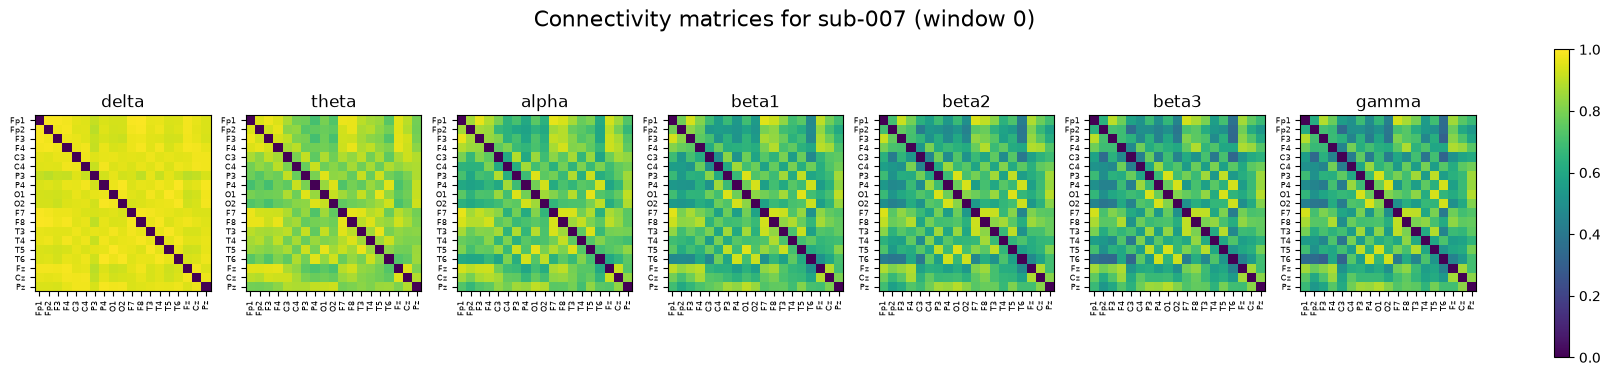

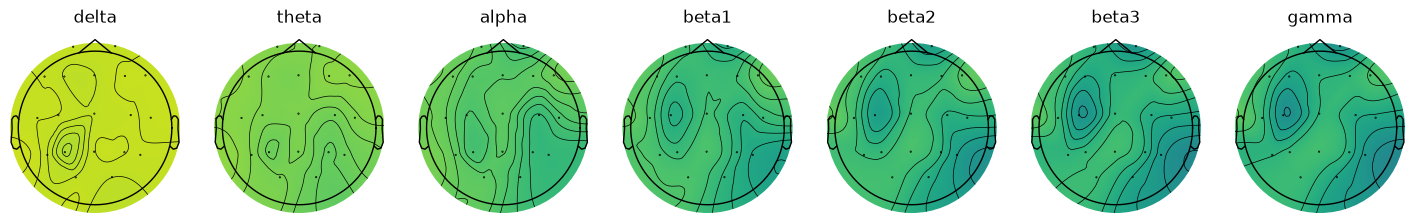

In [129]:
band_names = list(BANDS.keys())

# Reconstruct a symmetric (n_bands, n_channels, n_channels) tensor from the cached pair vectors.
conn_dense = pairs_to_dense(cached_window, n_channels=Chans, fill_diagonal=0.0)
print("conn_dense shape:", conn_dense.shape)

fig, axes = plt.subplots(1, len(band_names), figsize=(20, 4))
for b, (ax, band) in enumerate(zip(axes, band_names)):
    im = ax.imshow(conn_dense[b], vmin=0, vmax=1, cmap="viridis")
    ax.set_title(band)
    ax.set_xticks(range(len(one_epoch.ch_names)))
    ax.set_yticks(range(len(one_epoch.ch_names)))
    ax.set_xticklabels(one_epoch.ch_names, rotation=90, fontsize=6)
    ax.set_yticklabels(one_epoch.ch_names, fontsize=6)
fig.colorbar(im, ax=axes, fraction=0.02)

# add title
plt.suptitle(f"Connectivity matrices for {subject_id} (window {window_idx})", fontsize=16)

plt.show()

# Per-channel summary for topomaps: average each channel's connectivity to all others.
scc_per_channel_cached = conn_dense.mean(axis=-1)  # (n_bands, n_channels)

fig, axes = plt.subplots(1, len(band_names), figsize=(18, 4))
for b, (ax, band) in enumerate(zip(axes, band_names)):
    mne.viz.plot_topomap(
        scc_per_channel_cached[b],
        one_epoch.info,
        axes=ax,
        show=False,
        vlim=(0, 1),
        cmap="viridis",
    )
    ax.set_title(band)




plt.show()

#### compare inference times


In [61]:
from time import time

In [64]:
n_batches = 100
x = torch.randn(n_batches, Chans, sample_length, dtype=torch.float32)
cached_scc = torch.randn(n_batches, len(BANDS), Chans*(Chans-1)//2, dtype=torch.float32)

# xeegnet
current_time = time()
out = inference(xeegnet, x)
elapsed_time = time() - current_time
print(f"Elapsed time for {n_batches} batches: {elapsed_time:.4f} seconds for xeegnet")


# xeegnet_scc
current_time = time()
out = inference(xeegnet_scc, [x, cached_scc])
elapsed_time = time() - current_time
print(f"Elapsed time for {n_batches} batches: {elapsed_time:.4f} seconds for xeegnet_scc")

# shallownet
current_time = time()
out = inference(shallow_net, x)
elapsed_time = time() - current_time
print(f"Elapsed time for {n_batches} batches: {elapsed_time:.4f} seconds for shallownet")


Elapsed time for 100 batches: 0.0428 seconds for xeegnet
Elapsed time for 100 batches: 0.0144 seconds for xeegnet_scc
Elapsed time for 100 batches: 0.0809 seconds for shallownet


#### compare training time


In [65]:
trainloader, valloader, testloader, data_tuple = get_dataloaders_xysubjectids(
    dir_data=dir_data,
    participant_ids_train=participant_ids[:5],
    participant_ids_val=participant_ids[:3],
    df_metadata=df_metadata,
    parameters=PARAMETERS_DEFAULT,
    n_max=1000,
)

gamma = 0.995
# Define selfEEG's EarlyStopper with large patience to act as a model checkpoint
earlystop = selfeeg.ssl.EarlyStopping(
    patience=15, min_delta=1e-04, record_best_weights=True
)
validation_loss_args = []


Loaded derivative model windows: x shape (10, 19, 500), y shape (10,)
Loaded derivative model windows: x shape (6, 19, 500), y shape (6,)


KeyError: 'datasplit'

In [48]:
## xeegnet_scc training

model_curr = build_xeegnet_scc(nb_classes=nb_classes, Chans=Chans, Samples=sample_length, Fs=srate)

optimizer = torch.optim.Adam(model_curr.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

current_time = time()

loss_summary = train_model(
    model=model_curr,
    train_dataloader=trainloader,
    epochs=5,
    optimizer=optimizer,
    loss_func=lossMulti,
    lr_scheduler=scheduler,
    EarlyStopper=earlystop,
    validation_dataloader=valloader,
    validation_loss_func=lossVal,
    validation_loss_args=validation_loss_args,
    verbose=verbose,
    device=device,
    return_loss_info=True,
)

elaspsed_time = time() - current_time
print(f"Training completed in {elaspsed_time:.2f} seconds for xeegnet_scc.")

NameError: name 'gamma' is not defined

In [ ]:
# xeegnet training
model_curr = xeegnet

optimizer = torch.optim.Adam(model_curr.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

current_time = time()

loss_summary = train_model(
    model=model_curr,
    train_dataloader=trainloader,
    epochs=5,
    optimizer=optimizer,
    loss_func=lossMulti,
    lr_scheduler=scheduler,
    EarlyStopper=earlystop,
    validation_dataloader=valloader,
    validation_loss_func=lossVal,
    validation_loss_args=validation_loss_args,
    verbose=verbose,
    device=device,
    return_loss_info=True,
)

elaspsed_time = time() - current_time
print(f"Training completed in {elaspsed_time:.2f} seconds for xeegnet.")

epoch [1/5]
   val 1/1: 100%|███████████████| 2/2 [73.55 Batch/s, train_loss=1.71330, val_loss=2.25393]
no improvement after 15 epochs. Training stopped


RuntimeError: Error(s) in loading state_dict for xEEGNet:
	Missing key(s) in state_dict: "encoder.conv1.weight", "encoder.conv2.weight", "encoder.batch1.weight", "encoder.batch1.bias", "encoder.batch1.running_mean", "encoder.batch1.running_var". 
	Unexpected key(s) in state_dict: "base.encoder.conv1.weight", "base.encoder.conv2.weight", "base.encoder.batch1.weight", "base.encoder.batch1.bias", "base.encoder.batch1.running_mean", "base.encoder.batch1.running_var", "base.encoder.batch1.num_batches_tracked", "base.Dense.weight". 
	size mismatch for Dense.weight: copying a param with shape torch.Size([3, 14]) from checkpoint, the shape in current model is torch.Size([3, 7]).

In [ ]:
#### shallow net

# xeegnet training
model_curr = shallow_net

optimizer = torch.optim.Adam(model_curr.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

current_time = time()

loss_summary = train_model(
    model=model_curr,
    train_dataloader=trainloader,
    epochs=5,
    optimizer=optimizer,
    loss_func=lossMulti,
    lr_scheduler=scheduler,
    EarlyStopper=earlystop,
    validation_dataloader=valloader,
    validation_loss_func=lossVal,
    validation_loss_args=validation_loss_args,
    verbose=verbose,
    device=device,
    return_loss_info=True,
)

elaspsed_time = time() - current_time
print(f"Training completed in {elaspsed_time:.2f} seconds for shallow_net.")

epoch [1/5]
   val 1/1: 100%|███████████████| 2/2 [46.67 Batch/s, train_loss=0.84219, val_loss=1.30912]
no improvement after 15 epochs. Training stopped


RuntimeError: Error(s) in loading state_dict for ShallowNet:
	Missing key(s) in state_dict: "encoder.conv1.weight", "encoder.conv1.bias", "encoder.conv2.weight", "encoder.conv2.bias", "encoder.batch1.weight", "encoder.batch1.bias", "encoder.batch1.running_mean", "encoder.batch1.running_var", "Dense.bias". 
	Unexpected key(s) in state_dict: "base.encoder.conv1.weight", "base.encoder.conv2.weight", "base.encoder.batch1.weight", "base.encoder.batch1.bias", "base.encoder.batch1.running_mean", "base.encoder.batch1.running_var", "base.encoder.batch1.num_batches_tracked", "base.Dense.weight". 
	size mismatch for Dense.weight: copying a param with shape torch.Size([3, 14]) from checkpoint, the shape in current model is torch.Size([3, 1080]).

In [32]:
# """
# Benchmark the xEEGNet-SCC forward pass, isolating each branch.

# Answers three questions:
#   1. How much time is the encoder vs the SCC/spec branch?  -> confirms spec is the cost
#   2. Per-sample MNE loop vs one batched MNE call?          -> quantifies loop overhead
#   3. Do loop and batched SCC agree numerically?            -> safe to switch to batched/cache

# Drop this into your notebook environment where `xeegnet_scc` already exists,
# or edit the CONFIG block to build the objects. Run:  python benchmark_scc.py
# """

# import time
# import numpy as np
# import torch

# # ----------------------------------------------------------------------------
# # CONFIG  — point these at your already-built objects / dims
# # ----------------------------------------------------------------------------
# # from your_module import xeegnet_scc, Chans, sample_length, srate
# ENCODER = xeegnet_scc.base.encoder      # the bare xEEGNet encoder  (B,C,T) -> (B, emb)
# SPEC    = xeegnet_scc.spec              # the SpectralConnectivity module (B,C,T) -> (B, bands)
# B       = 100                           # batch size (your "n_batches")
# CHANS   = Chans
# SAMPLES = sample_length
# DEVICE  = next(xeegnet_scc.parameters()).device

# N_WARMUP = 2                            # discard first calls (imports, allocs, lazy init)
# N_REPEAT = 5                            # timed repetitions; we report min + mean


# # ----------------------------------------------------------------------------
# # Timing helper — CUDA-safe, warmup + repeats, reports min and mean
# # ----------------------------------------------------------------------------
# def timeit(fn, *, n_warmup=N_WARMUP, n_repeat=N_REPEAT, device=DEVICE):
#     is_cuda = torch.device(device).type == "cuda"
#     for _ in range(n_warmup):
#         fn()
#     if is_cuda:
#         torch.cuda.synchronize()
#     times = []
#     for _ in range(n_repeat):
#         t0 = time.perf_counter()
#         fn()
#         if is_cuda:
#             torch.cuda.synchronize()
#         times.append(time.perf_counter() - t0)
#     times = np.array(times)
#     return times.min(), times.mean(), times.std()


# def report(name, stats, batch_size=B):
#     lo, mean, std = stats
#     print(f"{name:28s} min={lo*1e3:9.2f} ms   "
#           f"mean={mean*1e3:9.2f} ± {std*1e3:6.2f} ms   "
#           f"per-sample={mean/batch_size*1e3:7.3f} ms")


# # ----------------------------------------------------------------------------
# # Benchmark
# # ----------------------------------------------------------------------------
# @torch.no_grad()
# def main():
#     torch.manual_seed(0)
#     x = torch.randn(B, CHANS, SAMPLES, dtype=torch.float32, device=DEVICE)

#     ENCODER.eval()
#     SPEC.eval()

#     print(f"device={DEVICE}  batch={B}  chans={CHANS}  samples={SAMPLES}\n")

#     # --- 1. isolate the two branches -------------------------------------
#     enc_stats  = timeit(lambda: ENCODER(x))
#     spec_stats = timeit(lambda: SPEC(x))
#     report("encoder", enc_stats)
#     report("spec (SCC, as-is)", spec_stats)

#     ratio = spec_stats[1] / max(enc_stats[1], 1e-9)
#     print(f"\n-> spec is ~{ratio:.0f}x the encoder. "
#           f"If ratio is large, the SCC branch is the bottleneck (as expected).\n")

#     # --- 2. per-sample loop vs one batched MNE call ----------------------
#     # Only runs if SPEC is the MNE version exposing these attributes.
#     if hasattr(SPEC, "freqs") and hasattr(SPEC, "bands"):
#         from mne_connectivity import spectral_connectivity_time

#         rows, cols = np.triu_indices(CHANS, k=1)
#         fmin = tuple(lo for _, (lo, _) in SPEC.bands)
#         fmax = tuple(hi for _, (_, hi) in SPEC.bands)
#         xnp  = x.detach().cpu().numpy()   # (B, C, T)

#         def batched_mne():
#             con = spectral_connectivity_time(
#                 xnp, freqs=SPEC.freqs, method=SPEC.method,
#                 mode=SPEC.mode, n_cycles=SPEC.n_cycles,
#                 fmin=fmin, fmax=fmax, faverage=True, average=False,
#                 indices=(rows, cols), sfreq=SPEC.Fs, verbose="ERROR",
#             )
#             return con.get_data().mean(axis=1)   # (B, bands)

#         batched_stats = timeit(batched_mne)
#         report("spec (batched MNE, 1 call)", batched_stats)

#         loop_speedup = spec_stats[1] / max(batched_stats[1], 1e-9)
#         print(f"\n-> batched MNE is ~{loop_speedup:.1f}x faster than the per-sample loop.\n")

#         # --- 3. numerical agreement: loop vs batched ---------------------
#         loop_out    = SPEC(x).detach().cpu().numpy()
#         batched_out = batched_mne()
#         max_diff    = np.abs(loop_out - batched_out).max()
#         print(f"max |loop - batched| = {max_diff:.3e}  "
#               f"({'MATCH' if max_diff < 1e-4 else 'DIFFERS — investigate'})")
#     else:
#         print("SPEC has no MNE attributes (freqs/bands) — skipping tests 2 & 3.")


# if __name__ == "__main__":
#     main()

## train models


In [203]:
# model = shallow_net
model_curr = xeegnet
# model_curr = build_xeegnet_scc(nb_classes=nb_classes, Chans=Chans, Samples=sample_length, Fs=srate)

In [195]:
optimizer = torch.optim.Adam(model_curr.parameters(), lr=lr)
gamma = 0.995
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

# factor = 0.5
# patience_scheduler = 10
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=factor, patience=patience_scheduler)

# Define selfEEG's EarlyStopper with large patience to act as a model checkpoint
earlystop = selfeeg.ssl.EarlyStopping(
    patience=15, min_delta=1e-04, record_best_weights=True
)

validation_loss_args = []
if taskToEval.casefold() == "alzheimer" or ("cognitive" in taskToEval.casefold()):
    lossFnc = lossMulti
else:
    lossFnc = lossBinary

In [196]:
# def load_participant_splits(split_path=None) -> dict[str, dict[str, list[int]]]:
#     if split_path is None:
#         split_path = Path("backend") / "ml" / "data_splits.json"
#     with split_path.open("r", encoding="utf-8") as file:
#         return json.load(file)

In [ ]:
model_version = 200

n_max = 1500

parameters = PARAMETERS_DEFAULT
training_parameters = TRAINING_PARAMETERS_DEFAULT

In [198]:
dir_data = os.path.join(dir_base, "data", "datasets", "ds004504")
split_index = model_version - 200

if not n_max:
    modelname = f"xeegnet_scc_model_v{model_version}.pt"
    model_path = PRETRAINED_MODEL_DIR / modelname
else:
    modelname = f"xeegnet_scc_model_v{model_version}_nmax{n_max}.pt"
    model_path = PRETRAINED_MODEL_DIR / modelname

split_path = Path(dir_base) / "backend" / "ml" / "data_splits.json"

participants_split = load_participant_splits(split_path=split_path)[str(split_index)]

df_metadata = load_metadata(dir_data=dir_data)
df_metadata["datasplit"] = "test"
df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["train"]), "datasplit"] = "train"
df_metadata.loc[df_metadata["participant_id_int"].isin(participants_split["val"]), "datasplit"] = "val"

participant_ids_train = participants_split["train"]
participant_ids_val = participants_split["val"]
participant_ids_test = participants_split["test"]

participant_ids_train_str = [gen_participant_id_long(pid) for pid in participant_ids_train]
participant_ids_val_str = [gen_participant_id_long(pid) for pid in participant_ids_val]
participant_ids_test_str = [gen_participant_id_long(pid) for pid in participant_ids_test]


In [199]:
# if True:
#     print(f"Training model version {model_version}...")
#     model, df_metadata = train_save_model(
#         model_path=model_path,
#         dir_data=dir_data,
#         df_metadata=df_metadata,
#         participant_ids_train=participants_split["train"],
#         participant_ids_val=participants_split["val"],
#         # n_max=n_max,
#     )

In [200]:
# df_metadata, trainloader, valloader, testloader, xy = get_train_val_test_loader(
#     dir_data=dir_data,
#     df_metadata=df_metadata,
#     participant_ids_train=participants_split["train"],
#     participant_ids_val=participants_split["val"],
#     n_max=n_max
# )

# x_train, y_train, x_val, y_val, x_test, y_test = xy

In [202]:
trainloader, valloader, testloader, xy_subjects = get_dataloaders_xysubjectids(
    dir_data=dir_data,
    participant_ids_train=participant_ids_train,
    participant_ids_val=participant_ids_val,
    df_metadata=df_metadata,
    parameters=parameters,
    n_max=n_max,
)

x_train, y_train, subject_ids_train, x_val, y_val, subject_ids_val, x_test, y_test, subject_ids_test = xy_subjects

Loaded derivative model windows: x shape (165, 19, 500), y shape (165,)
Loaded derivative model windows: x shape (54, 19, 500), y shape (54,)
Loaded derivative model windows: x shape (45, 19, 500), y shape (45,)


In [205]:
trainloader

In [206]:
loss_summary = train_model(
    model=build_xeegnet_scc(nb_classes=nb_classes, Chans=Chans, Samples=sample_length, Fs=srate),
    train_dataloader=trainloader,
    epochs=5,
    optimizer=optimizer,
    loss_func=lossFnc,
    lr_scheduler=scheduler,
    EarlyStopper=earlystop,
    validation_dataloader=valloader,
    validation_loss_func=lossVal,
    validation_loss_args=validation_loss_args,
    verbose=verbose,
    device=device,
    return_loss_info=True,
)

save_model(model_curr, model_path)

epoch [1/5]
   val 1/1: 100%|███████████████| 4/4 [ 5.04s/ Batch, train_loss=1.68643, val_loss=1.22570]
epoch [2/5]
   val 1/1: 100%|███████████████| 4/4 [ 5.29s/ Batch, train_loss=1.76832, val_loss=1.28169]
epoch [3/5]
   val 1/1: 100%|███████████████| 4/4 [ 5.98s/ Batch, train_loss=1.68444, val_loss=1.35481]
epoch [4/5]
   val 1/1: 100%|███████████████| 4/4 [ 5.91s/ Batch, train_loss=1.64463, val_loss=1.44511]
epoch [5/5]
   val 1/1: 100%|███████████████| 4/4 [ 5.89s/ Batch, train_loss=1.70521, val_loss=1.50365]
Model saved to C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_scc_model_v200_nmax1500.pt


## Evaluate model


In [32]:
# model = model_curr

In [33]:
from backend.ml.model import build_xeegnet

In [44]:
print(f"model version {model_version} ")
print(f"n_max: {n_max} ")

reload = True

n_max = None

# model_type = "xeegnet_scc"
model_type = "xeegnet"

if n_max:
    model_name = f"{model_type}_model_v{model_version}_nmax{n_max}.pt"
else:
    model_name = f"{model_type}_model_v{model_version}.pt"

model_path = PRETRAINED_MODEL_DIR / model_name
print(f"model path: {model_path}")

if reload:
    print(f"Reloading model from {model_path}...")
    if model_type == "xeegnet":
        model = build_xeegnet()

    elif model_type == "xeegnet_scc":
        model = build_xeegnet_scc()

    model = load_model_weights(model_path, model=model, device=device)

else:
    model = model_curr


model version 200 
n_max: 1500 
model path: C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_model_v200.pt
Reloading model from C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_model_v200.pt...
Loading model from C:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\ml\pretrained_models\xeegnet_model_v200.pt


In [45]:
def get_performances_metrics(y_true, y_pred):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "precision_macro": precision_score(y_true, y_pred, average="macro"),
        "recall_macro": recall_score(y_true, y_pred, average="macro"),
    }
    return metrics

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model_curr = model_curr.to(device)
model_curr = model

# cast from torch.cuda.FloatTensor to torch.FloatTensor
# x_train_eeg = torch.Tensor(x_train)
# x_train = x_train.to(device)


for dataset_type, x_data, y_data in zip(
    ["train", "val", "test"], [x_train, x_val, x_test], [y_train, y_val, y_test]
):
    print(f"Evaluating on {dataset_type} set:")
    x_data = torch.Tensor(x_data)
    x_data = x_data.to(device)
    with torch.no_grad():
        y_out = model_curr(x_data)
    y_pred = torch.argmax(y_out, dim=1).detach().cpu().numpy()
    metrics = get_performances_metrics(y_data, y_pred)
    print(metrics)
    print("\n")

Evaluating on train set:
{'accuracy': 0.703030303030303, 'f1_macro': 0.6633889055272704, 'precision_macro': 0.7077463774378475, 'recall_macro': 0.6647992530345471}


Evaluating on val set:
{'accuracy': 0.5925925925925926, 'f1_macro': 0.530171277997365, 'precision_macro': 0.5757575757575758, 'recall_macro': 0.5925925925925926}


Evaluating on test set:
{'accuracy': 0.4222222222222222, 'f1_macro': 0.35767195767195764, 'precision_macro': 0.36383442265795213, 'recall_macro': 0.35185185185185186}




In [47]:
classlabels = y_test

scores = get_performances(
    loader2eval=testloader,
    Model=model,
    device=device,
    nb_classes=nb_classes,
    return_scores=True,
    verbose=verbose,
    plot_confusion=True,
    class_labels=classlabels,
)
print(f"Balanced Accuracy: {scores['accuracy_weighted'] * 100: .2f} %")

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Font family ['DejaVu Sans'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Font family ['DejaVu Sans'] not found. Falling back to DejaVu Sans.


           |-----------------------------------------|
           |                SCORE SUMMARY            |
           |-----------------------------------------|
           |  Accuracy score:                 0.422  |
           |  Accuracy score weighted:        0.352  |
           |-----------------------------------------|
           |  Precision score micro:          0.422  |
           |  Precision score macro:          0.364  |
           |  Precision score weighted:       0.437  |
           |-----------------------------------------|
           |  Recall score micro:             0.422  |
           |  Recall score macro:             0.352  |
           |  Recall score weighted:          0.422  |
           |-----------------------------------------|
           |  F1-score micro:                 0.422  |
           |  F1-score macro:                 0.358  |
           |  F1-score weighted:              0.429  |
           |-----------------------------------------|
          

ValueError: Failed to find font DejaVu Sans:style=normal:variant=normal:weight=normal:stretch=normal:size=16.5, and fallback to the default font was disabled

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Font family ['DejaVu Sans'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Font family ['DejaVu Sans'] not found. Falling back to DejaVu Sans.


ValueError: Failed to find font DejaVu Sans:style=normal:variant=normal:weight=normal:stretch=normal:size=16.5, and fallback to the default font was disabled

<Figure size 1400x600 with 2 Axes>

#### shallow net 2


In [ ]:
if False:
    loss_summary = train_model(
        model=shallow_net_2,
        train_dataloader=trainloader,
        epochs=30,
        optimizer=optimizer,
        loss_func=lossFnc,
        lr_scheduler=scheduler,
        EarlyStopper=earlystop,
        validation_dataloader=valloader,
        validation_loss_func=lossVal,
        validation_loss_args=validation_loss_args,
        verbose=verbose,
        device=device,
        return_loss_info=True,
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    shallow_net = shallow_net.to(device)

    # cast from torch.cuda.FloatTensor to torch.FloatTensor
    # x_train_eeg = torch.Tensor(x_train)
    x_train = x_train.to(device)
    y_train_out = shallow_net(x_train)
    y_train_pred = torch.argmax(y_train_out, dim=1).detach().cpu().numpy()

    print("ShallowNet 2 performance on training set:")
    get_performances_metrics(y_train, y_train_pred)

## Scores


           |-----------------------------------------|
           |                SCORE SUMMARY            |
           |-----------------------------------------|
           |  Accuracy score:                 0.167  |
           |  Accuracy score weighted:        0.167  |
           |-----------------------------------------|
           |  Precision score micro:          0.167  |
           |  Precision score macro:          0.083  |
           |  Precision score weighted:       0.083  |
           |-----------------------------------------|
           |  Recall score micro:             0.167  |
           |  Recall score macro:             0.167  |
           |  Recall score weighted:          0.167  |
           |-----------------------------------------|
           |  F1-score micro:                 0.167  |
           |  F1-score macro:                 0.111  |
           |  F1-score weighted:              0.111  |
           |-----------------------------------------|
          

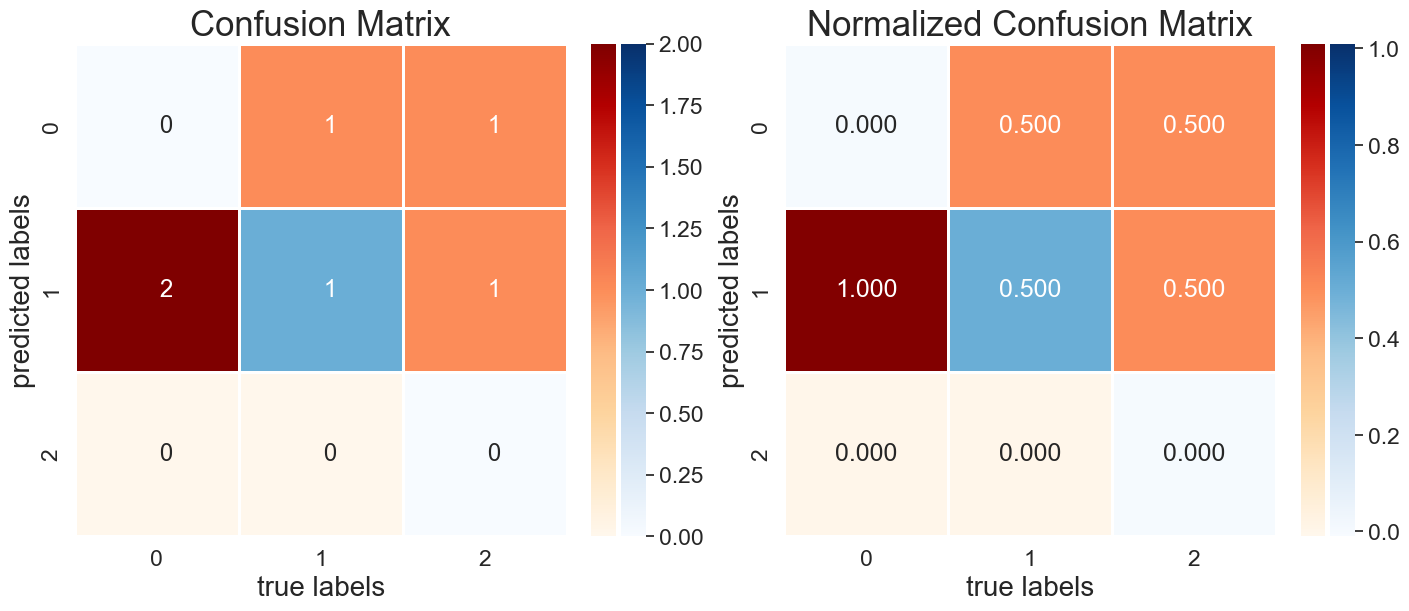

Balanced Accuracy:  16.67 %


In [ ]:
classlabels = y_test

scores = get_performances(
    loader2eval=testloader,
    Model=model_curr,
    device=device,
    nb_classes=nb_classes,
    return_scores=True,
    verbose=verbose,
    plot_confusion=True,
    class_labels=classlabels,
)
print(f"Balanced Accuracy: {scores['accuracy_weighted'] * 100: .2f} %")

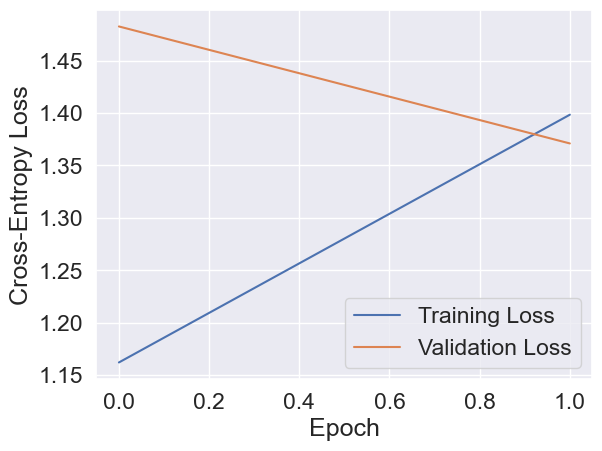

In [178]:
training_loss_curve = []
validation_loss_curve = []
# Iterate through the dictionary, filtering out entries with None values
for key, (train_loss, val_loss) in loss_summary.items():
    if train_loss is not None and val_loss is not None:
        training_loss_curve.append(train_loss)
        validation_loss_curve.append(val_loss)

scores["training_loss_curve"] = training_loss_curve
scores["validation_loss_curve"] = validation_loss_curve

plt.plot(training_loss_curve, label="Training Loss")
plt.plot(validation_loss_curve, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.show()

## Save the model


In [179]:
model_name = "xeeg_test_mini.pt"

dir_models = os.path.join(dir_shallownetXAI, "newmodels") + sep
model_path = os.path.join(dir_models, model_name)

dirResults = os.path.join(dir_shallownetXAI, "new_results") + sep
results_path = os.path.join(dirResults, f"{model_name[:-3]}_results.pickle")

In [180]:
results_path

'..\\..\\backend\\experiments_xeegnet\\shallownetXAI_main\\new_results\\xeeg_test_mini_results.pickle'

In [ ]:
print("model dir:", dir_models, os.path.isdir(dir_models))
print("model path:", model_path, os.path.abspath(model_path))
print("results dir:", dirResults, os.path.isdir(dirResults))
print(
    "results path:",
    results_path,
    os.path.abspath(results_path),
    os.path.exists(results_path),
)

model dir: ..\..\backend\experiments_xeegnet\shallownetXAI_main\newmodels\ True
model path: ..\..\backend\experiments_xeegnet\shallownetXAI_main\newmodels\xeeg_test_mini.pt c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\experiments_xeegnet\shallownetXAI_main\newmodels\xeeg_test_mini.pt
results dir: ..\..\backend\experiments_xeegnet\shallownetXAI_main\new_results\ True
results path: ..\..\backend\experiments_xeegnet\shallownetXAI_main\new_results\xeeg_test_mini_results.pickle c:\Users\grabn\Documents\CGV_2024\xeegVis_alll\all-in-on-eeg\backend\experiments_xeegnet\shallownetXAI_main\new_results\xeeg_test_mini_results.pickle True


In [183]:
save_model = False

if save_model:
    # Save the model
    model_curr.eval()
    model_curr.to(device="cpu")
    torch.save(model_curr.state_dict(), model_path)

    # Save the scores
    with open(results_path, "wb") as handle:
        pickle.dump(scores, handle, protocol=pickle.HIGHEST_PROTOCOL)